# 从 Transformer 到 Mini-GPT

> **前情回顾**：上一章你已经手写了 Self-Attention、Multi-Head 和 Transformer Block。
> **本章目标**：跟着 GPT-2 的结构图，把 Block 堆成一个可以输出 logits 的 Mini-GPT，并对照 Karpathy/nanoGPT 的写法。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


## 1. 学习地图

这章只回答一个问题：**已经有 Transformer Block 了，怎么变成 GPT？**

你可以把 GPT 想成一条流水线：

```text
Token IDs
  ↓
Token Embedding + Position Embedding
  ↓
Transformer Block × N
  ↓
LayerNorm
  ↓
Linear
  ↓
logits：每个位置预测下一个 token
```

重点不是背名字，而是盯住 shape：

```text
[batch, seq] → [batch, seq, d_model] → [batch, seq, vocab_size]
```


## 2. 先复用 Block

为了让本 Notebook 单独运行，我们先把上一章的三个零件放在这里。

你先不用重新理解每一行，先记住它们的职责：

1. `MultiHeadAttention`：让 token 互相看，但不能看未来。
2. `FeedForward`：每个 token 自己过一个小网络。
3. `TransformerBlock`：把 Attention、FFN、Residual、LayerNorm 串起来。


In [2]:
class MultiHeadAttention(nn.Module):
    """
    多头因果自注意力
    
    参数:
        d_model: 输入/输出维度
        num_heads: 注意力头数
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度
        
        # Q、K、V 的线性变换（把 num_heads 个头合并到矩阵操作里）
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        
        # 输出投影
        self.W_O = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        """
        输入: x shape = [batch, seq_len, d_model]
        输出:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape
        
        # 1. 线性变换 + 拆成多头
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. 注意力分数: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 3. Mask（把未来的位置设为 -inf）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # 4. Softmax
        weights = F.softmax(scores, dim=-1)
        
        # 5. 加权求和
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]
        
        # 6. 拼回头并投影
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


In [3]:
class FeedForward(nn.Module):
    """FFN：两层全连接，先扩 4 倍再压回"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """一个 Transformer 解码器层：Attention + FFN，各带残差 + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # Attention + 残差 + Norm
        x = self.norm2(x + self.ffn(x))              # FFN + 残差 + Norm
        return x


## 3. 跟着结构图手写 MiniGPT

现在开始搭整台模型。

第一步：Token ID 只是整数，不能直接送进神经网络，所以要查 `Embedding` 表。

第二步：同一个 token 出现在第 1 个位置和第 10 个位置，意思可能不同，所以要加 Position 信息。

第三步：经过多层 Transformer Block。

最后一步：把 hidden state 投影到词表大小，得到 logits。


In [4]:
# 复用 Part 3 的位置编码
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    """Mini GPT: Embedding → N×TransformerBlock → LayerNorm → 投影到词表"""
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)  # 投影到词表 → logits
    
    def forward(self, x):
        # x: [batch, seq_len]  token IDs
        batch_size, seq_len = x.shape
        x = self.token_emb(x) + self.pe[:seq_len, :]          # Embedding + Position
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        mask = mask.view(1, 1, seq_len, seq_len)
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln_final(x)
        return self.lm_head(x)  # [batch, seq_len, vocab_size]

## 4. 跑一次完整前向传播

模型现在还没训练，所以输出不聪明。

但我们先不关心答案好不好，只看数据有没有沿着结构图正确流动。


In [5]:
# 测试 MiniGPT
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=64, num_heads=4, num_layers=2)

total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,}, 可训练: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 前向传播: batch=2, seq_len=8
batch_input = torch.randint(0, vocab_size, (2, 8))
logits = model(batch_input)
print(f"\n输入: {batch_input.shape}  →  输出: {logits.shape}")
print(f"输出 = [batch=2, seq=8, vocab={vocab_size}] → 每个位置对每个词的 logits")
print(f"logits[0, 7, :5]: {logits[0, 7, :5].tolist()}  ← 样本 0 位置 7 预测下一 token 的分数")

总参数量: 103,966, 可训练: 103,966

输入: torch.Size([2, 8])  →  输出: torch.Size([2, 8, 30])
输出 = [batch=2, seq=8, vocab=30] → 每个位置对每个词的 logits
logits[0, 7, :5]: [1.4079980850219727, -0.3056167960166931, -1.065438985824585, 0.11685330420732498, 0.531089186668396]  ← 样本 0 位置 7 预测下一 token 的分数


In [6]:
# 跟着结构图跑一次：每一步都打印 shape
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
idx = torch.randint(0, vocab_size, (2, 6))

with torch.no_grad():
    token_vec = model.token_emb(idx)
    pos_vec = model.pe[:idx.shape[1], :]
    x = token_vec + pos_vec
    print(f"1. token + position: {x.shape}")

    mask = torch.tril(torch.ones(idx.shape[1], idx.shape[1]))
    mask = mask.view(1, 1, idx.shape[1], idx.shape[1])

    for block_id, block in enumerate(model.blocks, start=1):
        x = block(x, mask)
        print(f"2.{block_id} 经过 TransformerBlock: {x.shape}")

    x = model.ln_final(x)
    logits = model.lm_head(x)
    print(f"3. logits: {logits.shape}")

print("关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。")


1. token + position: torch.Size([2, 6, 32])
2.1 经过 TransformerBlock: torch.Size([2, 6, 32])
2.2 经过 TransformerBlock: torch.Size([2, 6, 32])
3. logits: torch.Size([2, 6, 30])
关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。


## 5. logits 是什么？

`logits` 是模型最后输出的原始分数。

如果 vocab 有 30 个 token，那么每个位置都会输出 30 个分数：

```text
logits[batch, 位置, token_id]
```

分数越高，模型越觉得这个 token 适合作为“下一个 token”。

训练时，我们会用 Cross-Entropy 让正确答案的分数变高。生成时，我们会对 logits 做 softmax，再抽样或取最大值。


## 6. 读取 Karpathy 的真实源码

现在不只做概念对照。

我们已经把两个仓库 clone 到本地：

```text
external/karpathy/nanoGPT
external/karpathy/minGPT
```

这一节直接读它们的源码文件，定位 GPT-2 风格模型最重要的几个类：

1. `CausalSelfAttention`
2. `MLP`
3. `Block`
4. `GPT`
5. `GPT.forward`

先看源码，再运行小模型。


In [7]:
# 读取 Karpathy 仓库里的真实 model.py
from pathlib import Path
import importlib.util
import sys
import time

def find_repo_root(start):
    """从当前工作目录向上找项目根目录"""
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "external" / "karpathy" / "nanoGPT" / "model.py").exists():
            return candidate
    raise FileNotFoundError("找不到 external/karpathy/nanoGPT/model.py")

REPO_ROOT = find_repo_root(Path.cwd())
NANOGPT_MODEL = REPO_ROOT / "external" / "karpathy" / "nanoGPT" / "model.py"
MINGPT_ROOT = REPO_ROOT / "external" / "karpathy" / "minGPT"
MINGPT_MODEL = MINGPT_ROOT / "mingpt" / "model.py"

print(f"repo root: {REPO_ROOT}")
print(f"nanoGPT model.py exists: {NANOGPT_MODEL.exists()}")
print(f"minGPT  model.py exists: {MINGPT_MODEL.exists()}")


repo root: /Users/sanbu/Code/2026重要开源项目/modern-llm-notebook
nanoGPT model.py exists: True
minGPT  model.py exists: True


In [8]:
# 在源码中定位关键类和 forward
KEYWORDS = [
    "class CausalSelfAttention",
    "class MLP",
    "class Block",
    "class GPT",
    "def forward",
]

def find_lines(path, keywords):
    lines = path.read_text().splitlines()
    hits = []
    for i, line in enumerate(lines, start=1):
        stripped = line.strip()
        for keyword in keywords:
            if stripped.startswith(keyword):
                hits.append((i, stripped))
    return hits

for name, path in [("nanoGPT", NANOGPT_MODEL), ("minGPT", MINGPT_MODEL)]:
    print()
    print(f"=== {name}: key lines in model.py ===")
    for line_no, text in find_lines(path, KEYWORDS):
        print(f"line {line_no:3d}: {text}")

print()
print("观察：两个仓库的主干名字几乎一样，都是 Attention → Block → GPT.forward。")



=== nanoGPT: key lines in model.py ===
line  26: def forward(self, input):
line  29: class CausalSelfAttention(nn.Module):
line  52: def forward(self, x):
line  78: class MLP(nn.Module):
line  87: def forward(self, x):
line  94: class Block(nn.Module):
line 103: def forward(self, x):
line 109: class GPTConfig:
line 118: class GPT(nn.Module):
line 170: def forward(self, idx, targets=None):

=== minGPT: key lines in model.py ===
line  26: def forward(self, x):
line  29: class CausalSelfAttention(nn.Module):
line  52: def forward(self, x):
line  73: class Block(nn.Module):
line  90: def forward(self, x):
line  95: class GPT(nn.Module):
line 260: def forward(self, idx, targets=None):

观察：两个仓库的主干名字几乎一样，都是 Attention → Block → GPT.forward。


### 读 `GPT.forward` 的主线

下面只截取 `GPT.forward` 附近的关键行。

你读的时候抓住一条线：

```text
idx
  → token embedding wte
  → position embedding wpe
  → Transformer blocks h
  → final layer norm ln_f
  → lm_head
  → logits / loss
```


In [9]:
# 打印 nanoGPT 的 GPT.forward 关键片段
nano_lines = NANOGPT_MODEL.read_text().splitlines()
start = next(i for i, line in enumerate(nano_lines) if line.strip().startswith("def forward"))

print("=== nanoGPT GPT.forward excerpt ===")
for line_no in range(start + 1, start + 42):
    print(f"{line_no:3d}: {nano_lines[line_no - 1]}")


=== nanoGPT GPT.forward excerpt ===
 26:     def forward(self, input):
 27:         return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)
 28: 
 29: class CausalSelfAttention(nn.Module):
 30: 
 31:     def __init__(self, config):
 32:         super().__init__()
 33:         assert config.n_embd % config.n_head == 0
 34:         # key, query, value projections for all heads, but in a batch
 35:         self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
 36:         # output projection
 37:         self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
 38:         # regularization
 39:         self.attn_dropout = nn.Dropout(config.dropout)
 40:         self.resid_dropout = nn.Dropout(config.dropout)
 41:         self.n_head = config.n_head
 42:         self.n_embd = config.n_embd
 43:         self.dropout = config.dropout
 44:         # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
 45:         se

### 跑 nanoGPT 小模型

这里不下载 GPT-2 权重，也不跑完整训练。

我们只做一件事：直接加载 `nanoGPT/model.py` 里的 `GPT` 类，用一个很小的配置跑 forward 和 loss。

这能验证：真实工程代码的输出形状，和我们自己的 MiniGPT 是同一种结构。


In [10]:
# 直接 import 本地 clone 的 nanoGPT/model.py
spec = importlib.util.spec_from_file_location("karpathy_nanogpt_model", NANOGPT_MODEL)
nanogpt_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(nanogpt_model)

nano_config = nanogpt_model.GPTConfig(
    block_size=16,
    vocab_size=64,
    n_layer=2,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
nano_model = nanogpt_model.GPT(nano_config)
nano_model.eval()

idx = torch.randint(0, nano_config.vocab_size, (2, 8))
targets = torch.randint(0, nano_config.vocab_size, (2, 8))

with torch.no_grad():
    nano_logits, nano_loss = nano_model(idx, targets)

print("=== nanoGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(nano_logits.shape)}")
print(f"loss:         {nano_loss.item():.4f}")
print(f"params:       {nano_model.get_num_params():,}")
print("观察：logits 仍然是 [batch, seq, vocab_size]。")


number of parameters: 0.03M
=== nanoGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1788
params:       27,520
观察：logits 仍然是 [batch, seq, vocab_size]。


### 跑 minGPT 小模型

`minGPT` 更教学化，代码更短。

它的主干也一样：`GPT` 里面放 `wte`、`wpe`、多层 `Block`、`ln_f`、`lm_head`。


In [11]:
# import 本地 clone 的 minGPT
if str(MINGPT_ROOT) not in sys.path:
    sys.path.insert(0, str(MINGPT_ROOT))

from mingpt.model import GPT as MinGPT

min_config = MinGPT.get_default_config()
min_config.model_type = None
min_config.n_layer = 2
min_config.n_head = 2
min_config.n_embd = 32
min_config.vocab_size = 64
min_config.block_size = 16
min_config.embd_pdrop = 0.0
min_config.resid_pdrop = 0.0
min_config.attn_pdrop = 0.0

torch.manual_seed(42)
min_model = MinGPT(min_config)
min_model.eval()

with torch.no_grad():
    min_logits, min_loss = min_model(idx, targets)

min_params = sum(p.numel() for p in min_model.parameters())
print("=== minGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(min_logits.shape)}")
print(f"loss:         {min_loss.item():.4f}")
print(f"params:       {min_params:,}")
print("观察：minGPT 和 nanoGPT 的 forward 接口很接近。")


number of parameters: 0.03M
=== minGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1648
params:       30,080
观察：minGPT 和 nanoGPT 的 forward 接口很接近。


## 7. 用线图看真实代码的行为

现在我们不只看一次 forward。

我们跑几个小实验：

1. 模型变深，参数量怎么变？
2. 序列变长，forward 时间怎么变？
3. 三个模型在同一批随机数据上的 loss 大概在哪里？

这些实验不是为了比较谁更强，因为模型都没训练。

重点是观察结构带来的形状、参数量和运行成本。


number of parameters: 0.01M
number of parameters: 0.03M
number of parameters: 0.05M
number of parameters: 0.08M


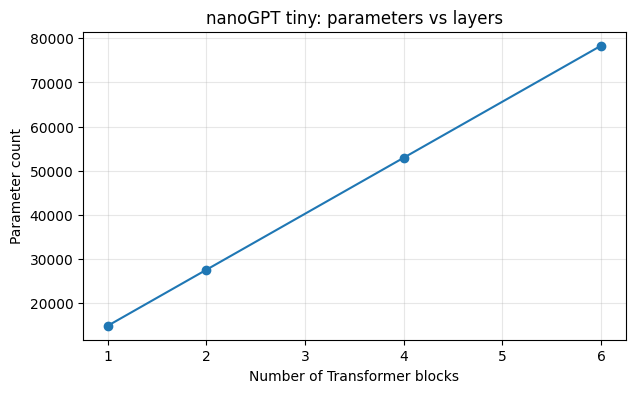

n_layer=1: params=14,816
n_layer=2: params=27,520
n_layer=4: params=52,928
n_layer=6: params=78,336
观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。


In [12]:
# 实验 1：层数增加时，nanoGPT 参数量怎么变
layer_counts = [1, 2, 4, 6]
nano_param_counts = []

for n_layer in layer_counts:
    cfg = nanogpt_model.GPTConfig(
        block_size=16,
        vocab_size=64,
        n_layer=n_layer,
        n_head=2,
        n_embd=32,
        dropout=0.0,
        bias=True,
    )
    model = nanogpt_model.GPT(cfg)
    nano_param_counts.append(model.get_num_params())

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, nano_param_counts, marker="o")
plt.xlabel("Number of Transformer blocks")
plt.ylabel("Parameter count")
plt.title("nanoGPT tiny: parameters vs layers")
plt.grid(True, alpha=0.3)
plt.show()

for n_layer, params in zip(layer_counts, nano_param_counts):
    print(f"n_layer={n_layer}: params={params:,}")

print("观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。")


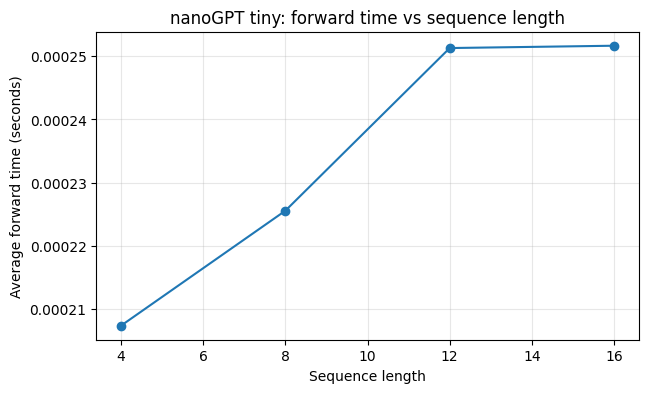

seq_len= 4: avg_forward_time=0.000207s
seq_len= 8: avg_forward_time=0.000226s
seq_len=12: avg_forward_time=0.000251s
seq_len=16: avg_forward_time=0.000252s
观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。


In [13]:
# 实验 2：序列长度增加时，forward 时间怎么变
# 注意：CPU 上单次运行波动很大，所以每个长度跑多次取平均。
def benchmark_forward(model, seq_len, repeats=20):
    sample = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    target = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    with torch.no_grad():
        model(sample, target)  # warmup
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeats):
            model(sample, target)
    elapsed = time.perf_counter() - start
    return elapsed / repeats

seq_lengths = [4, 8, 12, 16]
forward_times = []
for seq_len_value in seq_lengths:
    forward_times.append(benchmark_forward(nano_model, seq_len_value))

plt.figure(figsize=(7, 4))
plt.plot(seq_lengths, forward_times, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Average forward time (seconds)")
plt.title("nanoGPT tiny: forward time vs sequence length")
plt.grid(True, alpha=0.3)
plt.show()

for seq_len_value, seconds in zip(seq_lengths, forward_times):
    print(f"seq_len={seq_len_value:2d}: avg_forward_time={seconds:.6f}s")

print("观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。")


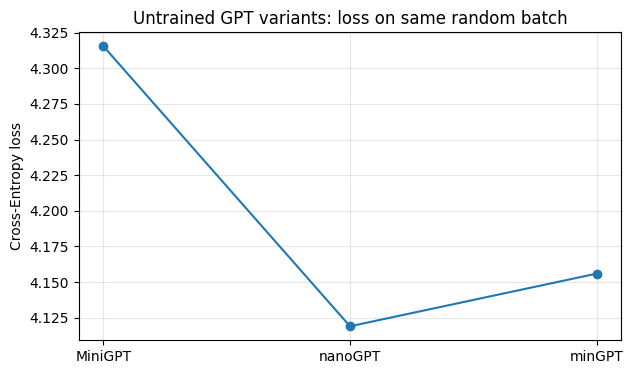

MiniGPT : loss=4.3154
nanoGPT : loss=4.1190
minGPT  : loss=4.1560
观察：没训练的模型 loss 都接近随机猜测的水平。
随机猜 64 个 token 的理论量级约为 log(64) = 4.1589


In [14]:
# 实验 3：同一批随机数据上，MiniGPT / nanoGPT / minGPT 的 loss
# 三个模型都没训练，所以这里只看数量级和接口一致性。
torch.manual_seed(123)
compare_idx = torch.randint(0, 64, (4, 12))
compare_targets = torch.randint(0, 64, (4, 12))

mini_for_compare = MiniGPT(vocab_size=64, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
mini_for_compare.eval()

with torch.no_grad():
    mini_logits = mini_for_compare(compare_idx)
    mini_loss = F.cross_entropy(
        mini_logits.reshape(-1, mini_logits.size(-1)),
        compare_targets.reshape(-1),
    )
    nano_compare_logits, nano_compare_loss = nano_model(compare_idx, compare_targets)
    min_compare_logits, min_compare_loss = min_model(compare_idx, compare_targets)

names = ["MiniGPT", "nanoGPT", "minGPT"]
losses = [mini_loss.item(), nano_compare_loss.item(), min_compare_loss.item()]

plt.figure(figsize=(7, 4))
plt.plot(names, losses, marker="o")
plt.ylabel("Cross-Entropy loss")
plt.title("Untrained GPT variants: loss on same random batch")
plt.grid(True, alpha=0.3)
plt.show()

for name, loss_value in zip(names, losses):
    print(f"{name:8s}: loss={loss_value:.4f}")

print("观察：没训练的模型 loss 都接近随机猜测的水平。")
print(f"随机猜 64 个 token 的理论量级约为 log(64) = {math.log(64):.4f}")


## 8. 对照之后再看 MiniGPT

现在把三份代码放在一起：

| 教学版 | nanoGPT / minGPT | 意义 |
|:---|:---|:---|
| `MiniGPT` | `GPT` | 整台模型 |
| `TransformerBlock` | `Block` | 一层 decoder block |
| `MultiHeadAttention` | `CausalSelfAttention` | causal self-attention |
| `FeedForward` | `MLP` | token 内部的非线性加工 |
| `token_emb` | `wte` | token embedding |
| `pe` / `wpe` | `wpe` | position embedding |
| `lm_head` | `lm_head` | hidden state → vocab logits |

读真实工程代码时，先沿着 `GPT.forward` 走，不要一开始就陷进训练脚本、optimizer、checkpoint。


## 9. Special Tokens

Mini-GPT 会输出 logits，但它还需要一些“边界符号”。

比如：哪里开始、哪里结束、哪里是 padding、哪里是思考草稿。

```text
<BOS>       begin of sequence，告诉模型：这里开始
<EOS>       end of sequence，告诉模型：生成到这里可以停
<PAD>       padding，告诉模型：这个位置只是补齐，不是真内容
<think>     thinking start，告诉模型：下面进入思考区间
</think>    thinking end，告诉模型：思考区间结束，下面给最终回答
```

`<think>` 不会让模型自动变聪明。它只是一个符号。

模型要学会用它，训练数据里必须反复出现这种格式。


In [15]:
# 演示：给 Mini-GPT 的词表加入新的 special tokens
base_vocab = {
    "用户": 0,
    "助手": 1,
    "答案": 2,
    "357": 3,
    "289": 4,
    "103173": 5,
}

special_tokens = ["<BOS>", "<EOS>", "<PAD>", "<think>", "</think>"]

vocab = base_vocab.copy()
for token in special_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

print("新增后的 special token ID:")
for token in special_tokens:
    print(f"  {token:8s} -> {vocab[token]}")

print()
print("关键观察：<think> 和 </think> 现在有独立 ID，")
print("模型才能把它们当成边界符号，而不是普通文字碎片。")

新增后的 special token ID:
  <BOS>    -> 6
  <EOS>    -> 7
  <PAD>    -> 8
  <think>  -> 9
  </think> -> 10

关键观察：<think> 和 </think> 现在有独立 ID，
模型才能把它们当成边界符号，而不是普通文字碎片。


In [16]:
# 演示：一条带 <think> 的训练样本长什么样
sample_tokens = [
    "<BOS>",
    "用户",
    "357",
    "289",
    "助手",
    "<think>",
    "357",
    "289",
    "103173",
    "</think>",
    "答案",
    "103173",
    "<EOS>",
]

sample_ids = [vocab[token] for token in sample_tokens]

print("训练样本 token:")
print(sample_tokens)
print()
print("训练样本 ID:")
print(sample_ids)
print()
print("关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。")

训练样本 token:
['<BOS>', '用户', '357', '289', '助手', '<think>', '357', '289', '103173', '</think>', '答案', '103173', '<EOS>']

训练样本 ID:
[6, 0, 3, 4, 1, 9, 3, 4, 5, 10, 2, 5, 7]

关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。


新增 special tokens 后，词表变大了。

词表一变大，Embedding 表也要变大，因为每个 token 都要有自己的向量。


In [17]:
# 用小矩阵演示：新增 token 后，Embedding 为什么要扩容
old_vocab_size = len(base_vocab)
new_vocab_size = len(vocab)
d_model = 8

torch.manual_seed(42)
old_embedding = nn.Embedding(old_vocab_size, d_model)
new_embedding = nn.Embedding(new_vocab_size, d_model)

# 旧 token 的向量复制过去，新 token 的向量保留随机初始化，后续训练会更新它们
with torch.no_grad():
    new_embedding.weight[:old_vocab_size] = old_embedding.weight

print(f"旧词表大小: {old_vocab_size}")
print(f"新词表大小: {new_vocab_size}")
print(f"Embedding 形状: {tuple(new_embedding.weight.shape)}")
print()
print("关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。")
print("这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。")

旧词表大小: 6
新词表大小: 11
Embedding 形状: (11, 8)

关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。
这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。


## 小结

确认你已经懂了这些：

1. ✅ GPT = Embedding + Position + 多层 Transformer Block + 输出投影
2. ✅ 中间 hidden state 的形状通常保持 `[batch, seq, d_model]`
3. ✅ 最后 `lm_head` 才把维度变成 `vocab_size`
4. ✅ logits 是预测下一个 token 的原始分数
5. ✅ Karpathy/nanoGPT 的名字更工程化，但骨架和我们手写版一致
6. ✅ special tokens 需要独立 ID，也需要扩容 Embedding

下一步：训练。Loss 到底怎么算，模型怎么从乱猜变得会接话。


---

## 本章作业：Mini-GPT

这题检查你是否理解生成时常见的 temperature。

> **使用 AI 的注意事项**：可以让 AI 解释 temperature 对概率分布的影响，但请自己写出缩放 logits 的那一行。


### 作业 3：现代用法 —— temperature 调整 logits

现代 LLM 生成时经常用 temperature 控制随机性。temperature 越小，分布越尖锐；越大，分布越平。

**小提示**：常见写法是 `scaled_logits = logits / temperature`。


In [ ]:
# 作业 3：temperature 缩放 logits 填空
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
temperature = 0.5

# TODO：用 temperature 缩放 logits
scaled_logits = """在这里缩放 logits"""

assert not isinstance(scaled_logits, str), "请先替换三引号里的占位内容"
assert torch.allclose(scaled_logits, torch.tensor([2.0, 4.0, 6.0])), scaled_logits
print("✅ 作业 3 通过：temperature < 1 会让 logits 差距变大，分布更尖锐")
